In [1]:
image_size = 224  
num_channels = 3  


In [2]:
# Define a function to preprocess the images 
def process_image(image_path):
    
    image_path = image_path.replace("E:\\TARUN\\Projects\\Autism Detection\\Data\\data_png",'/kaggle/input/autism/')
    image_path = image_path.replace("\\",'/')
    
    # Read the original image
    original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Apply Canny edge detection
    edges = cv2.Canny(original_image, threshold1=30, threshold2=100)  # Adjust thresholds as needed

    # Find the contours of the edges
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Find the largest contour (the edges of the MRI structure)
    if len(contours) > 0:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)

        # Crop the image based on the largest contour
        cropped_image = original_image[y:y+h, x:x+w]

    else:
        # If no contours are found, set cropped_image to the original image
        cropped_image = original_image

    # Resize to the desired image size (224x224)
    image_size = (224, 224)
    cropped_image = cv2.resize(cropped_image, image_size)

    # Convert single-channel image to RGB
    cropped_image = cv2.cvtColor(cropped_image, cv2.COLOR_GRAY2RGB)

    # Min-Max Normalization
    min_value = 0
    max_value = 255
    cropped_image = (cropped_image - min_value) / (max_value - min_value)

    return cropped_image


In [3]:
import tensorflow as tf
import pandas as pd
import cv2

num_classes = 2

# Load your data from CSV files using pandas
train_data = pd.read_csv('/kaggle/input/autism-csv/extracted_random_labels_train.csv')
test_data = pd.read_csv('/kaggle/input/autism-csv/extracted_random_labels_test.csv')
val_data = pd.read_csv('/kaggle/input/autism-csv/extracted_random_labels_validation.csv')

# Extract features and labels from the data
X_train, y_train = train_data['Image_path'], train_data['LABEL']
X_test, y_test = test_data['Image_path'], test_data['LABEL']
X_val, y_val = val_data['Image_path'], val_data['LABEL']

def create_custom_dataset(image_paths, labels, num_classes):
    dataset = tf.data.Dataset.from_generator(
        generator=lambda: ((process_image(image_path), label) for image_path, label in zip(image_paths, labels)),
        output_signature=(tf.TensorSpec(shape=(image_size, image_size, num_channels), dtype=tf.float32), tf.TensorSpec(shape=(), dtype=tf.int32))
    )
    return dataset

# Create custom Dataset classes
train_dataset = create_custom_dataset(X_train, y_train, num_classes)
val_dataset = create_custom_dataset(X_val, y_val, num_classes)
test_dataset = create_custom_dataset(X_test, y_test, num_classes)


/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [ ]:
import pickle  # Import the pickle module

# Preprocess and save the custom datasets as a list
preprocessed_train_data = list(train_dataset.as_numpy_iterator())
preprocessed_val_data = list(val_dataset.as_numpy_iterator())
preprocessed_test_data = list(test_dataset.as_numpy_iterator())

# Save preprocessed datasets to files using pickle
with open("/kaggle/working/preprocessed_train_data.pkl", "wb") as file:
    pickle.dump(preprocessed_train_data, file)

with open("/kaggle/working/preprocessed_val_data.pkl", "wb") as file:
    pickle.dump(preprocessed_val_data, file)

with open("/kaggle/working/preprocessed_test_data.pkl", "wb") as file:
    pickle.dump(preprocessed_test_data, file)


In [4]:
train_count = train_dataset.reduce(0, lambda x, _: x + 1).numpy()
val_count = val_dataset.reduce(0, lambda x, _: x + 1).numpy()
test_count = test_dataset.reduce(0, lambda x, _: x + 1).numpy()
print(f"Number of samples in train dataset: {train_count}")
print(f"Number of samples in validation dataset: {val_count}")
print(f"Number of samples in test dataset: {test_count}")


Number of samples in train dataset: 72367
Number of samples in validation dataset: 8041
Number of samples in test dataset: 20102


In [5]:
import tensorflow as tf
from tensorflow.keras import layers

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches


In [6]:
class PatchEncoding(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patches):
        # Linear projection of patches
        encoded_patches = self.projection(patches)
        
        # Add position embeddings
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        position_embeddings = self.position_embedding(positions)
        encoded_patches = encoded_patches + position_embeddings

        return encoded_patches


In [ ]:
# Define the MLP function
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x


In [7]:
def mlp(x, hidden_units, projection_dim):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(0.1)(x)
        x = layers.Dense(projection_dim)(x)
    return x


In [8]:
def transformer_encoder(inputs, _):
    skip_1 = inputs
    x = layers.LayerNormalization()(inputs)
    x = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=projection_dim
    )(x, x)
    #x = layers.Dropout(0.1)(x)  # Add dropout
    x = layers.Add()([x, skip_1])

    skip_2 = x
    x = layers.LayerNormalization()(x)
    x = mlp(x, hidden_units, projection_dim)
    x = layers.Dropout(0.2)(x)  # Add dropout
    x = layers.Add()([x, skip_2])

    return x

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def create_vit_classifier(input_shape, num_classes, num_patches, projection_dim, transformer_layers, num_heads, transformer_units, mlp_head_units, patch_size, hidden_units):
    inputs = layers.Input(shape=input_shape)

    # Create patches.
    patches = Patches(patch_size)(inputs)

    # Encode patches.
    encoded_patches = PatchEncoding(num_patches, projection_dim)(patches)

    # Create multiple layers of the Transformer block.
    for _ in range(transformer_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)

        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)

        # Skip connection 1.
        x2 = layers.Add()([attention_output, encoded_patches])

        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)

        # MLP.
        x3 = mlp(x3, hidden_units=hidden_units, dropout_rate=0.1)

        # Skip connection 2.
        encoded_patches = layers.Add()([x3, x2])

    # Create a [batch_size, projection_dim] tensor.
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)

    # Add MLP.
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.5)

    # Classify outputs.
    logits = layers.Dense(num_classes)(features)

    # Create the Keras model.
    model = keras.Model(inputs=inputs, outputs=logits)

    return model


In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def create_vit_classifier(input_shape, num_classes, num_patches, projection_dim, transformer_layers, num_heads, transformer_units, mlp_head_units, patch_size, hidden_units):
    inputs = layers.Input(shape=input_shape)

    # Create patches.
    patches = Patches(patch_size)(inputs)

    # Encode patches.
    encoded_patches = PatchEncoding(num_patches, projection_dim)(patches)

    # Create multiple layers of the Transformer block.
    for _ in range(transformer_layers):
        # Use your transformer_encoder function here instead of manual implementation.
        encoded_patches = transformer_encoder(encoded_patches, _)

    # Classification Head
    x = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    x = layers.GlobalAveragePooling1D()(x)  # Change to GlobalAveragePooling1D
    x = layers.Dense(projection_dim, activation="relu")(x)  # Additional Dense Layer
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(num_classes, activation="softmax")(x)

    # Create the Keras model.
    model = keras.Model(inputs=inputs, outputs=x)

    return model

In [ ]:
import tensorflow as tf
from tqdm import tqdm
import matplotlib.pyplot as plt
from tensorflow.keras.metrics import Accuracy, AUC, Precision, Recall
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

input_shape = (224, 224, 3)  # Adjust this to your image dimensions
num_classes = 3
num_patches = 196  # The number of patches
projection_dim = 128  # Dimension of the embedded patches
transformer_layers = 6  # The number of layers in the Transformer stack
num_heads = 4  # The number of attention heads
transformer_units = [
    projection_dim * 2,
    projection_dim,
]  # Size of the transformer layers
mlp_head_units = [512, 256]  # The number of units in the Multi-Layer Perceptron (MLP) head
patch_size = 16
hidden_units = transformer_units
batch_size = 64
num_epochs = 75  # Number of epochs


In [10]:
import tensorflow as tf
from tqdm import tqdm
import matplotlib.pyplot as plt
from tensorflow.keras.metrics import Accuracy, AUC, Precision, Recall
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay

from tensorflow.keras.callbacks import EarlyStopping

import numpy as np

input_shape = (224, 224, 3)  # Adjust this to your image dimensions
num_classes = 3
num_patches = 196  # The number of patches
projection_dim = 64  # Dimension of the embedded patches
transformer_layers = 12  # The number of layers in the Transformer stack
num_heads = 8  # The number of attention heads
transformer_units = [
    projection_dim * 2,
    projection_dim,
]  # Size of the transformer layers
mlp_head_units = [256, 128]  # The number of units in the Multi-Layer Perceptron (MLP) head
patch_size = 16
hidden_units = transformer_units
batch_size = 64
num_epochs = 50  # Number of epochs
#dropout_rate = 0.2


In [11]:
# Create and compile the model
model = create_vit_classifier(
    input_shape,
    num_classes,
    num_patches,
    projection_dim,
    transformer_layers,
    num_heads,
    transformer_units,
    mlp_head_units,
    patch_size,
    hidden_units
)

model.compile(
    optimizer=Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, epsilon=1e-7),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)


In [12]:
import numpy as np
from tqdm import tqdm
import tensorflow as tf

def train_and_validate(model, train_dataset, val_dataset, num_epochs, batch_size):
    train_accuracies, train_losses = [], []
    valid_accuracies, valid_losses = [], []
    
    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs} (Training)")

        train_acc_values, train_loss_values = [], []

        # Training loop with a progress bar
        for images, labels in tqdm(train_dataset.batch(batch_size), total=train_count//batch_size, desc=f'Epoch {epoch + 1}/{num_epochs} (Training)'):
            # Assuming you have a single scalar label for each image
            labels = tf.reshape(labels, (-1,))  # Reshape to a 1D array
            labels = tf.cast(labels, dtype=tf.float32)

            # Train on a batch
            train_metrics = model.train_on_batch(images, labels, return_dict=True)

            train_acc_values.append(train_metrics['accuracy'])
            train_loss_values.append(train_metrics['loss'])

        # Calculate and store the average accuracy and loss for this epoch
        avg_train_acc = np.mean(train_acc_values)
        avg_train_loss = np.mean(train_loss_values)
        train_accuracies.append(avg_train_acc)
        train_losses.append(avg_train_loss)
        print(f"Train Accuracy: {avg_train_acc:.4f}, Train Loss: {avg_train_loss:.4f}")

        print(f"Epoch {epoch + 1}/{num_epochs} (Validation)")

        valid_acc_values, valid_loss_values = [], []

        # Validation loop with a progress bar
        for images, labels in tqdm(val_dataset.batch(batch_size), total=val_count//batch_size, desc=f'Epoch {epoch + 1}/{num_epochs} (Validation)'):
            # Assuming you have a single scalar label for each image
            labels = tf.reshape(labels, (-1,))  # Reshape to a 1D array
            labels = tf.cast(labels, dtype=tf.float32)

            # Validate on a batch
            val_metrics = model.test_on_batch(images, labels, return_dict=True)

            valid_acc_values.append(val_metrics['accuracy'])
            valid_loss_values.append(val_metrics['loss'])

        # Calculate and store the average accuracy and loss for this epoch
        avg_valid_acc = np.mean(valid_acc_values)
        avg_valid_loss = np.mean(valid_loss_values)
        valid_accuracies.append(avg_valid_acc)
        valid_losses.append(avg_valid_loss)
        print(f"Validation Accuracy: {avg_valid_acc:.4f}, Validation Loss: {avg_valid_loss:.4f}")
        
    model.save('/kaggle/working/vit_adam.h5')
    
    return train_accuracies, train_losses, valid_accuracies, valid_losses


In [13]:
train_accuracies, train_losses, valid_accuracies, valid_losses = train_and_validate(model, train_dataset, val_dataset, num_epochs, batch_size)


Epoch 1/50 (Training)


Epoch 1/50 (Training):   0%|          | 0/1130 [00:00<?, ?it/s]/opt/conda/lib/python3.10/site-packages/keras/backend.py:5612: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(
Epoch 1/50 (Training): 1131it [11:30,  1.64it/s]                          


Train Accuracy: 0.5206, Train Loss: 0.6978
Epoch 1/50 (Validation)


Epoch 1/50 (Validation): 126it [00:55,  2.25it/s]                         


Validation Accuracy: 0.5370, Validation Loss: 0.6903
Epoch 2/50 (Training)


...

Validation Accuracy: 0.6125, Validation Loss: 0.7131
Epoch 50/50 (Training)


Epoch 50/50 (Training): 1131it [10:22,  1.82it/s]                          


Train Accuracy: 0.6853, Train Loss: 0.5480
Epoch 50/50 (Validation)


Epoch 50/50 (Validation): 126it [00:54,  2.31it/s]                         


Validation Accuracy: 0.6156, Validation Loss: 0.6976


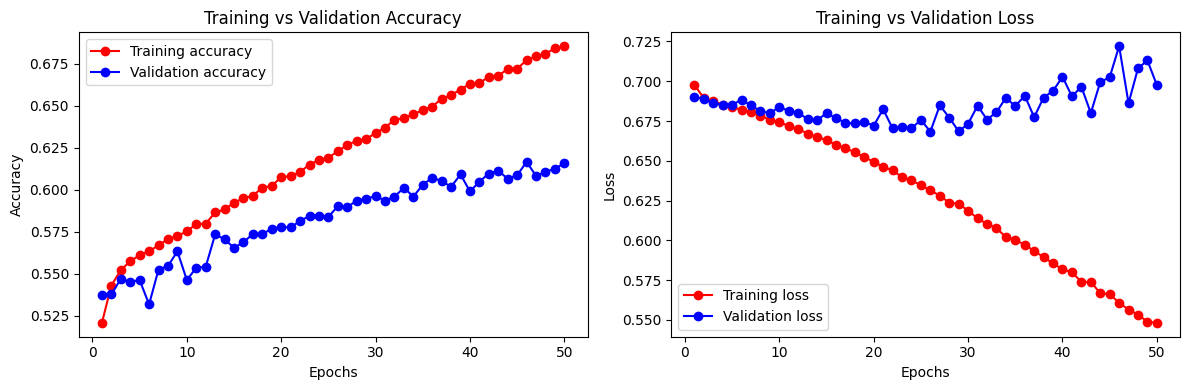

In [14]:
import matplotlib.pyplot as plt

def plot_training_history(train_accuracies, train_losses, valid_accuracies, valid_losses):
    epochs = range(1, len(train_accuracies) + 1)

    # Plot training and validation accuracy
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_accuracies, 'r', label='Training accuracy', marker='o')
    plt.plot(epochs, valid_accuracies, 'b', label='Validation accuracy', marker='o')
    plt.title('Training vs Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot training and validation loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_losses, 'r', label='Training loss', marker='o')
    plt.plot(epochs, valid_losses, 'b', label='Validation loss', marker='o')
    plt.title('Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call the function to plot the graphs
plot_training_history(train_accuracies, train_losses, valid_accuracies, valid_losses)


In [15]:
test_labels = []
for images, labels in test_dataset:
    test_labels.append(labels.numpy())

# Convert the list to a NumPy array
test_labels = np.array(test_labels, dtype=int)


In [16]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
import tensorflow as tf

# Define an empty list to store predictions
test_predictions = []

# Assuming you have a batch size of 64, adjust it accordingly
batch_size = 64

# Testing loop
for images, labels in test_dataset.batch(batch_size):
    # Make predictions for a batch of test data
    predictions = model(images)
    # Convert the sparse categorical predictions to labels
    predictions = tf.argmax(predictions, axis=1)
    test_predictions.extend(predictions.numpy())

# Calculate the metrics
test_predictions = np.array(test_predictions)
accuracy = accuracy_score(test_labels, test_predictions)
roc_auc = roc_auc_score(test_labels, test_predictions)
precision = precision_score(test_labels, test_predictions)
recall = recall_score(test_labels, test_predictions)
f1 = f1_score(test_labels, test_predictions)

# Print the metrics
print("Test Accuracy:", accuracy)
print("Test ROC AUC Score:", roc_auc)
print("Test Precision:", precision)
print("Test Recall:", recall)
print("Test F1 Score:", f1)


Test Accuracy: 0.6161078499651776
Test ROC AUC Score: 0.6186430665591955
Test Precision: 0.5868940910277609
Test Recall: 0.6942557134033354
Test F1 Score: 0.6360763970761613


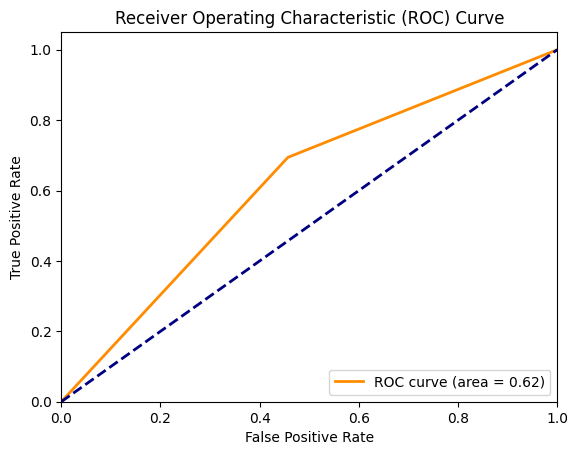

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score, auc
import matplotlib.pyplot as plt

# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, test_predictions)

# Calculate the AUC (Area Under the Curve)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


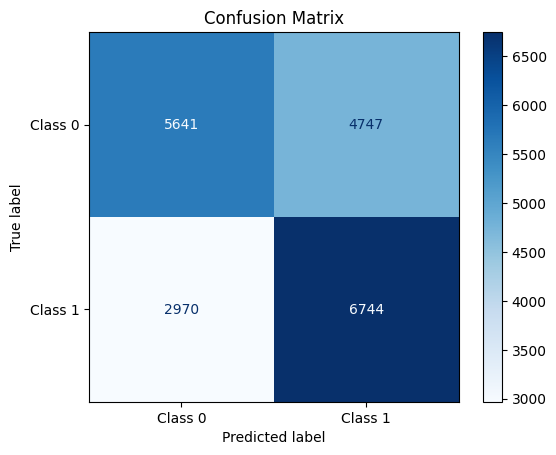

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate the confusion matrix
cm = confusion_matrix(test_labels, test_predictions)

# Display the confusion matrix with numbers
labels = ['Class 0', 'Class 1']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues, values_format="d")
plt.title('Confusion Matrix')
plt.show()


In [ ]:
train_accuracies, train_losses, valid_accuracies, valid_losses = train_and_validate(model, train_dataset, val_dataset, num_epochs, batch_size)


Epoch 1/50 (Training)


Epoch 1/50 (Training):   0%|          | 0/1130 [00:00<?, ?it/s]/opt/conda/lib/python3.10/site-packages/keras/backend.py:5612: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(
Epoch 1/50 (Training):  67%|██████▋   | 761/1130 [06:24<02:43,  2.26it/s] 